# XGBoost — Multi-Class Classification (Softmax + Second-Order Boosting)

---

## 1. Problem Setup

Given a dataset:

$$
\{(x_i, y_i)\}_{i=1}^{N}, \quad x_i \in \mathbb{R}^D, \quad y_i \in \{0,1,\dots,K-1\}
$$

The goal is to model class probabilities:

$$
P(y = k \mid x)
$$

for all classes $k = 1, \dots, K$.

---

## 2. Additive Model (Logit Space)

XGBoost builds **class-wise additive functions**:

$$
F_k^{(0)}(x) = 0
$$

$$
F_k^{(t)}(x) = F_k^{(t-1)}(x) + \eta \, f_k^{(t)}(x)
$$

where:

- $F_k(x)$ = raw score (logit) for class $k$  
- $f_k^{(t)}(x)$ = tree for class $k$ at iteration $t$  
- $\eta$ = learning rate  

---

## 3. Softmax Transformation

Raw scores are converted into probabilities:

$$
P(y = k \mid x) = \frac{\exp(F_k(x))}{\sum_{j=1}^{K} \exp(F_j(x))}
$$

For numerical stability:

$$
F_k(x) \leftarrow F_k(x) - \max_j F_j(x)
$$

---

## 4. Loss Function (Cross-Entropy)

$$
\mathcal{L} = - \sum_{i=1}^{N} \sum_{k=1}^{K} I(y_i = k) \log p_{ik}
$$

where:

- $p_{ik} = P(y_i = k \mid x_i)$  
- $I(y_i = k)$ = indicator function  

---

## 5. One-Hot Encoding

Define:

$$
I_{ik} =
\begin{cases}
1 & \text{if } y_i = k \\
0 & \text{otherwise}
\end{cases}
$$

---

## 6. Gradient and Hessian

Using Softmax + Cross-Entropy:

### I Gradient:

$$
g_{ik} = \frac{\partial \mathcal{L}}{\partial F_k(x_i)} = p_{ik} - I_{ik}
$$



### II Hessian:

$$
h_{ik} = \frac{\partial^2 \mathcal{L}}{\partial F_k(x_i)^2} = p_{ik}(1 - p_{ik})
$$

To ensure stability:

$$
h_{ik} \geq \epsilon
$$

---

## 7. Second-Order Objective

Using Taylor expansion:

$$
\mathcal{L}^{(t)} \approx \sum_{i=1}^{N} \sum_{k=1}^{K}
\left[
g_{ik} f_k(x_i) + \frac{1}{2} h_{ik} f_k^2(x_i)
\right]
$$

---

## 8. Tree Model (Per Class)

Each class $k$ has its own tree:

$$
f_k(x) = w_j \quad \text{if } x \in R_j
$$

---

## 9. Regularized Objective

For a tree:

$$
\mathcal{L}^{(t)} = \sum_{j=1}^{J}
\left[
G_j w_j + \frac{1}{2}(H_j + \lambda) w_j^2
\right] + \gamma J
$$

where:

$$
G_j = \sum_{i \in R_j} g_{ik}, \quad
H_j = \sum_{i \in R_j} h_{ik}
$$

---

## 10. Optimal Leaf Weight

$$
w_j^* = -\frac{G_j}{H_j + \lambda}
$$

---

## 11. Split Gain

$$
\text{Gain} =
\frac{1}{2}
\left(
\frac{G_L^2}{H_L + \lambda}
+
\frac{G_R^2}{H_R + \lambda}
-
\frac{G^2}{H + \lambda}
\right)
- \gamma
$$

Split if:

$$
\text{Gain} > 0
$$

---

## 12. Model Update

For each class:

$$
F_k(x_i) \leftarrow F_k(x_i) + \eta \, f_k^{(t)}(x_i)
$$

---

## 13. Final Prediction

### I Probabilities:

$$
p_k(x) = \frac{\exp(F_k(x))}{\sum_{j=1}^{K} \exp(F_j(x))}
$$



### II Class Label:

$$
\hat{y} = \arg\max_k F_k(x)
$$

---

## 14. Algorithm Summary

For $t = 1$ to $T$:

$$
\text{Compute } p_{ik} = \text{Softmax}(F_k(x_i))
$$

$$
g_{ik} = p_{ik} - I_{ik}
$$

$$
h_{ik} = p_{ik}(1 - p_{ik})
$$

For each class $k$:

$$
\text{Fit tree } f_k^{(t)}(x) \text{ using } (g_{ik}, h_{ik})
$$

$$
F_k(x) \leftarrow F_k(x) + \eta \, f_k^{(t)}(x)
$$

---

## 15. Role of Hyperparameters

### I Learning Rate ($\eta$)

$$
F_k \leftarrow F_k + \eta f_k
$$

- Controls step size  
- Prevents overfitting  



### II Lambda ($\lambda$)

$$
w_j = -\frac{G_j}{H_j + \lambda}
$$

- Shrinks leaf weights  



### III Gamma ($\gamma$)

$$
\text{Gain} - \gamma
$$

- Controls tree complexity  



### IV Feature Fraction

- Random subset of features per split  
- Reduces variance  

---

## 16. Intuition

- One tree per class per iteration  
- Learns residual errors in **probability space**  
- Uses **second-order optimization** for faster convergence  
- Softmax ensures valid probability distributions  

---

## 17. Summary

$$
\text{XGBoost Multi-Class} = \text{Boosting} + \text{Softmax} + \text{Second-Order Optimization}
$$

- Efficient  
- Stable  
- Scales well to multiple classes  

---

In [1]:
class LeafNode:
    """
    A leaf node in the XGBoost tree.

    Attributes:
        weight (float): The optimal leaf weight calculated using 
                        the gradients (G) and hessians (H).
    """
    def __init__(self,weights):
        self.weights = weights

In [2]:
class DecisionNode:
    """
    An intermediate node that splits the data based on a feature threshold.

    Attributes:
        feature (int): The index of the feature used for splitting.
        threshold (float): The value used to divide the data.
        left (Node): The child node for samples where feature <= threshold.
        right (Node): The child node for samples where feature > threshold.
    """
    def __init__(self,feature,threshold,left,right):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right

In [3]:
class XGBoostTree:
    """
    A single regression tree built using second-order Taylor expansion.
    
    Attributes:
        max_depth (int): Maximum depth of the tree.
        min_samples_split (int): Minimum samples required to attempt a split.
        feature_fraction (float): Percentage of features to consider per tree.
        gamma (float): Minimum gain required to create a new split.
        lambda_ (float): L2 regularization term on leaf weights.
        root (Node): The root of the trained tree (DecisionNode or LeafNode).
    """
    def __init__(self,max_depth=10,min_samples_split=1,feature_fraction=1,gamma=1,lambda_=1):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.feature_fraction = feature_fraction
        self.gamma = gamma
        self.lambda_ = lambda_

        # Validate
        if type(self.max_depth) != int or self.max_depth <= 0:
            raise ValueError('Max depth must be a positive integer')
        if type(self.min_samples_split) != int or self.min_samples_split <= 0:
            raise ValueError('Min samples split must be a positive integer')
        if not (0 < self.feature_fraction <= 1):
            raise ValueError("feature_fraction must be in the range (0, 1].")
        if self.gamma < 0:
            raise ValueError("gamma must be positive")
        if self.lambda_ < 0:
            raise ValueError("lambda must be positive")

        self.root=None
        self.X = None
        self.g = None
        self.h = None

    def _stopping_condition(self,indices,depth):
        """
        Evaluates whether the tree growth should stop at the current node.

        Args:
            indices (np.ndarray): The indices of the samples currently in the node.
            depth (int): The current depth level of the tree.

        Returns:
            bool: True if the node should become a leaf, False otherwise.
        """
        # Depth Constraint: Prevents the tree from becoming too complex and memorizing noise (overfitting).
        if depth >= self.max_depth:
            return True
        # Sample Size Constraint: Ensures there is enough statistical evidence to justify another split.
        if len(indices) < self.min_samples_split:
            return True
        # 3. Purity Check: If all remaining samples have the same gradient/hessian, no further gain can be achieved.
        if len(np.unique(self.g[indices])) <= 1:
             return True
        return False

    def _feature_sampling(self):
        """
        Performs column subsampling (Feature Fraction). 
        
        Randomly selects a subset of features to consider for the current node. 
        This reduces the variance of the model and prevents dominant features 
        from over-structuring every tree.

        Returns:
            np.ndarray: An array of randomly selected feature indices.
        """
        # Calculate how many features to select based on feature_fraction
        num_sampled_features = max(1,int(round(self.feature_fraction * self.num_features)))
        # Randomly choose indices without replacement
        sampled_features = np.random.choice(self.num_features,num_sampled_features,replace=False)
        return sampled_features

    def _find_all_thresholds(self,sampled_features,indices):
        """
        Identifies potential split points for each sampled feature. 
        
        Instead of testing every unique value, it calculates the midpoints 
        between sorted unique values to find the most balanced thresholds.

        Args:
            sampled_features (np.ndarray): Indices of features to evaluate.
            indices (np.ndarray): Indices of the samples in the current node.

        Returns:
            list: A list of numpy arrays, where each array contains the 
                  candidate thresholds for a specific feature.
        """
        all_thresholds = []
        for feature in sampled_features:
            # Get unique values for the specific feature among the current samples
            unique_vals = np.unique(self.X[indices,feature])
            # No possible split if all values are the same
            if len(unique_vals)==1:
                all_thresholds.append(np.array([]))
            else:
                # Calculate midpoints between adjacent sorted values
                averages = (unique_vals[1:] + unique_vals[:-1])/2
                all_thresholds.append(averages)

        return all_thresholds

    def _leaf_weight(self,G,H):
        """
        Calculates the optimal weight (prediction value) for a leaf node.
        
        The weight is derived by setting the derivative of the objective 
        function to zero, including L2 regularization (lambda).
        
        Formula: w = -G / (H + lambda)

        Args:
            G (float): Sum of gradients in the leaf.
            H (float): Sum of hessians in the leaf.

        Returns:
            float: The calculated leaf weight.
        """
        # Numerical stability to prevent division by zero
        eps=1e-10
        weight = - G/(H+self.lambda_ + eps)
        return weight

    def _computeGH(self,indices):
        """
        Aggregates the gradients (g) and hessians (h) for a specific 
        subset of data points.

        Args:
            indices (np.ndarray): Indices of the samples in the current node.

        Returns:
            tuple: (Sum of Gradients, Sum of Hessians)
        """
        G = np.sum(self.g[indices])
        H = np.sum(self.h[indices])

        return G,H

    def _local_gain(self,G,H):
        """
        Calculates the structure score for a specific node (or candidate leaf).
        
        The score represents how much the loss is reduced by the current 
        sum of gradients and hessians.
        
        Formula: Gain_node = G^2 / (H + lambda)

        Args:
            G (float): Sum of gradients in the node.
            H (float): Sum of hessians in the node.

        Returns:
            float: The structure score for this node.
        """
        # Numerical stability
        eps = 1e-10
        return G**2/(H + self.lambda_ + eps)

    def _compute_score(self,left_gain,right_gain,node_gain):
        """
        Calculates the total gain of a potential split. 
        
        This is the core "Split Criterion" for XGBoost. It compares the scores 
        of the two new child nodes against the score of the original parent node, 
        penalizing for complexity using gamma.
        
        Formula: 0.5 * (Gain_L + Gain_R - Gain_parent) - gamma

        Args:
            left_gain (float): Score of the potential left child.
            right_gain (float): Score of the potential right child.
            node_gain (float): Score of the parent node before splitting.

        Returns:
            float: The net gain. If negative, the split is usually rejected.
        """
        return 0.5*(left_gain+right_gain-node_gain) - self.gamma

    def _split(self,feature,indices,threshold):
        """
        Partitions the current sample indices into left and right groups 
        based on a feature threshold.

        Args:
            feature (int): The index of the feature to split on.
            indices (np.ndarray): Current sample indices in the node.
            threshold (float): The value to compare against.

        Returns:
            tuple: (left_indices, right_indices)
        """
        condition = self.X[indices,feature] <= threshold
        return indices[condition] , indices[~condition]

    def _find_best_feature_threshold_score(self,sampled_features,all_thresholds,indices):
        """
        Greedily searches for the best feature and threshold to split the data.
        
        This method iterates through all sampled features and their candidate 
        thresholds, calculates the resulting Gain for each, and tracks the 
        one that provides the highest score.

        Args:
            sampled_features (np.ndarray): Indices of features to evaluate.
            all_thresholds (list): List of candidate threshold arrays for each feature.
            indices (np.ndarray): Current sample indices in the node.

        Returns:
            tuple: (best_feature, best_threshold, best_score)
                - best_feature: Index of the feature that yielded the highest gain.
                - best_threshold: The value to split on.
                - best_score: The highest gain achieved (must be > 0 to split).
        """
        best_score = -np.inf
        best_feature = None
        best_threshold = None
        # Calculate parent node statistics once to compare against children
        G_node , H_node = self._computeGH(indices)
        node_gain = self._local_gain(G_node , H_node)

        for i,feature in enumerate(sampled_features):
            threshold_for_current_feature = all_thresholds[i]
            feature_mask = self.X[indices,feature]

            if len(threshold_for_current_feature)==0:
                continue
            for threshold in threshold_for_current_feature:
                # Partition indices based on current threshold
                condition = feature_mask<=threshold
                left_indices , right_indices = indices[condition], indices[~condition]
                # Skip split if it results in an empty child
                if len(left_indices) == 0 or len(right_indices) == 0:
                    continue
                # Compute stats and gain for this specific split
                G_L , H_L = self._computeGH(left_indices)
                G_R , H_R = self._computeGH(right_indices)
                left_gain , right_gain = self._local_gain(G_L , H_L) , self._local_gain(G_R , H_R)
                # Calculate net gain (Total Children Gain - Parent Gain - Gamma)
                score = self._compute_score(left_gain , right_gain,node_gain)
                # Track the best candidate
                if score > best_score:
                    best_score=score
                    best_threshold = threshold
                    best_feature = feature


        return best_feature,best_threshold,best_score


    def _find_best_split(self,indices):
        # Sample features (Feature Subsampling)
        sampled_features = self._feature_sampling()
        all_thresholds = self._find_all_thresholds(sampled_features,indices)
        best_feature,best_threshold,best_score =  self._find_best_feature_threshold_score(sampled_features,all_thresholds,indices)

        return best_feature,best_threshold,best_score

    def _build_tree(self,indices,depth):
        """
        Recursive function to grow the tree.
        """
        G , H = self._computeGH(indices)
        # Check stopping conditions
        if self._stopping_condition(indices,depth):
            return LeafNode(self._leaf_weight(G,H))
            
        # Find the best split
        best_feature,best_threshold,best_score = self._find_best_split(indices)

        if best_score <=0:
            return LeafNode(self._leaf_weight(G,H))

        left_indices , right_indices = self._split(best_feature,indices,best_threshold)

        if len(left_indices)==0 or len(right_indices)==0:
            return LeafNode(self._leaf_weight(G,H))

        left_child = self._build_tree(left_indices,depth+1)
        right_child = self._build_tree(right_indices,depth+1)

        return DecisionNode(best_feature, best_threshold, left_child, right_child)

    def fit(self,X,g,h):
        """
        Builds the tree by recursively finding the best splits.

        Args:
            X (np.ndarray): Feature matrix.
            g (np.ndarray): Gradients of the loss function.
            h (np.ndarray): Hessians of the loss function.
        """
        X = np.asarray(X)
        g = np.asarray(g)
        h = np.asarray(h)

        self.X = X
        self.g = g
        self.h = h

        N , self.num_features = self.X.shape
        indices = np.arange(N)

        self.root = self._build_tree(indices,0)

    def _predict_single(self,x,node):
        """
        Traverses the tree to find the leaf weight for a single sample.
        """
        if isinstance(node,LeafNode):
            return node.weights
        else:
            if x[node.feature] <= node.threshold:
                return self._predict_single(x,node.left)
            else:
                return self._predict_single(x,node.right)

    def predict(self,X):
        """
        Predicts the output for each sample in X.
        """
        y_pred = np.array([self._predict_single(x,self.root) for x in X])
        return y_pred

    def _count_leaves(self,node):
        """
        Recursively counts the total number of terminal (leaf) nodes in the tree.
        
        Args:
            node (Node): The starting node (root).
            
        Returns:
            int: Total count of leaf nodes.
        """
        if isinstance(node,LeafNode):
            return 1
        else :
            return self._count_leaves(node.left) + self._count_leaves(node.right)

    def _unique_weights(self, node):
        """
        Traverses the tree to collect all predicted leaf weights. 
        Useful for analyzing weight distribution and shrinkage.
        
        Args:
            node (Node): The starting node (root).
            
        Returns:
            list: A list of all floating-point weights stored in the leaves.
        """
        if isinstance(node, LeafNode):
            return [node.weights]
        # Combine weights from left and right branches
        return self._unique_weights(node.left) + self._unique_weights(node.right)

In [4]:
class XGBoostMultiClassClassifier:
    """
    XGBoost Classifier for Multi-class classification tasks.

    This model trains an ensemble of decision trees. For each boosting round, 
    it builds one tree per class to predict the residuals (gradients) of the 
    Softmax loss function.

    Attributes:
        n_estimators (int): Number of boosting rounds (sets of trees).
        max_depth (int): Maximum depth of each individual decision tree.
        min_samples_split (int): Minimum samples required to split a node.
        gamma (float): Minimum loss reduction required to make a further partition.
        lambda_ (float): L2 regularization term on leaf weights.
        learning_rate (float): Step size shrinkage used to prevent overfitting.
        all_models (list): Nested list storing trained trees for each round and class.
        num_classes (int): The number of unique classes detected in the target.
    """
    def __init__(self,n_estimators=10,max_depth=10,min_samples_split=1,feature_fraction=1,gamma=1,lambda_=1,learning_rate=0.01,
                random_state=123):
        """Initializes the model with hyperparameters."""
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.feature_fraction = feature_fraction
        self.gamma = gamma
        self.lambda_ = lambda_
        self.learning_rate = learning_rate
        self.random_state = random_state
        
        self.all_models = None
        self.num_classes = None
        
         # Validate
        if type(self.n_estimators) != int or self.n_estimators <= 0:
            raise ValueError('N estimators must be a positive integer')
        if type(self.max_depth) != int or self.max_depth <= 0:
            raise ValueError('Max depth must be a positive integer')
        if type(self.min_samples_split) != int or self.min_samples_split <= 0:
            raise ValueError('Min samples split must be a positive integer')
        if not (0 < self.feature_fraction <= 1):
            raise ValueError("feature_fraction must be in the range (0, 1].")
        if self.gamma < 0:
            raise ValueError("gamma must be positive")
        if self.lambda_ < 0:
            raise ValueError("lambda must be positive")
        if self.learning_rate <= 0:
            raise ValueError("learning rate must be positive")

    def _stable_softmax(self,F_k):
        """
        Computes the softmax activation in a numerically stable way.
        
        Args:
            F_k (np.ndarray): Raw score matrix of shape (num_samples, num_classes).
            
        Returns:
            np.ndarray: Probabilities for each class per sample.
        """
        eps = 1e-10
        # Stability Trick: Subtract the max value from each row. 
        # This prevents np.exp() from overflowing (becoming 'inf') with large positive scores.
        # Mathematically, softmax(x) == softmax(x - C).
        F_k = F_k - np.max(F_k,axis=1,keepdims=True)
        # Exponentiate the adjusted scores
        p_k = np.exp(F_k)
        # Divide by the sum of exponentials (the denominator) to normalize into probabilities
        p_k /= np.sum(p_k,axis=1, keepdims=True)
        # Clip values to avoid 0 or 1 exactly, preventing log(0) errors in loss calculations
        p_k = np.clip(p_k,eps,1-eps)
        return p_k

    def compute_grad_hess(self,p,I):
        """
        Calculates the first and second order derivatives of the Cross-Entropy loss.
        
        Args:
            p (np.ndarray): Predicted probabilities (Softmax output).
            I (np.ndarray): One-hot encoded ground truth indicators.
            
        Returns:
            tuple: (gradients, hessians) as numpy arrays.
        """
        eps=1e-10
        # Gradient: The difference between predicted probability and the ground truth.
        # If p=0.7 and I=1.0, grad is -0.3 (model needs to increase confidence).
        # If p=0.2 and I=0.0, grad is 0.2 (model needs to decrease confidence).
        g = p-I
        # Hessian: The second derivative of the Cross-Entropy loss for Softmax.
        # Formula: p * (1 - p). This represents the 'curvature' or variance.
        # High uncertainty (p=0.5) results in a larger Hessian (0.25).
        h = p*(1-p)
        # Ensure Hessian is not too small; used in denominator: weight = -g / (h + lambda)
        # np.maximum prevents division by zero or extremely unstable updates.
        h = np.maximum(h,eps)

        return g,h

    def fit(self,X,y):
        """
        Trains the XGBoost ensemble.
        
        The fitting process involves:
        1. Initializing log-odds (F_k) to zero.
        2. For each round:
            a. Computing Softmax probabilities.
            b. Calculating Gradients and Hessians.
            c. Fitting a tree for each class to predict the negative gradient.
            d. Updating the log-odds with a scaled version of tree predictions.

        Args:
            X (np.ndarray): Training feature matrix of shape (N, D).
            y (np.ndarray): Target labels of shape (N,).
        """
        X = np.asarray(X)
        y = np.asarray(y)

        if X.ndim==1:
            X = X.reshape(-1,1)

        y = y.reshape(-1)

        np.random.seed(self.random_state)

        num_samples , features = X.shape
        self.classes_, y_encoded = np.unique(y, return_inverse=True)
        self.num_classes = len(self.classes_)
        # Initialize raw scores (logits) to zero for all samples and classes 
        # Initially, Softmax(0) will give equal probability (1/K) to all classes
        F_k = np.zeros((num_samples,self.num_classes))

        self.all_models = [[] for i in range(self.n_estimators)]
        
        # One-hot encode targets: Create a matrix where 1 indicates the correct class
        Indicator = np.zeros_like(F_k)
        Indicator[np.arange(num_samples), y_encoded] =1

        # Boosting rounds (m)
        for m in range(self.n_estimators):
            # Convert current raw scores into probabilities using Softmax
            p_k = self._stable_softmax(F_k)
            # Calculate Gradients (p - y) and Hessians (p * (1-p))
            g_ik , hess_ik = self.compute_grad_hess(p_k,Indicator)

            for k in range(self.num_classes):
                model = XGBoostTree(max_depth=self.max_depth ,min_samples_split=self.min_samples_split,
                                    feature_fraction=self.feature_fraction,gamma=self.gamma,lambda_=self.lambda_)
                
                # Fit the tree to predict the negative gradient (residuals) for class k
                model.fit(X,g_ik[:,k],hess_ik[:,k])
                
                y_pred = model.predict(X)
                # Update the global raw scores per class (Log-Odds)
                F_k[:,k] = F_k[:,k]  + self.learning_rate * y_pred
                
                self.all_models[m].append(model)
                
    def predict_proba(self,X):
        """
        Predicts the class probabilities for the input samples.
    
        This method calculates the final log-odds (F_k) by summing the 
        weighted predictions of all trees in the ensemble and then 
        applying the Softmax function.
    
        Args:
            X (np.ndarray): Input feature matrix of shape (num_samples, num_features).
    
        Returns:
            np.ndarray: A matrix of shape (num_samples, num_classes) where 
                        each row contains the probability distribution over classes.
        """
        X = np.asarray(X)
        # Ensure input is 2D even if a single sample is passed
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        num_samples = X.shape[0]
        # Start from a clean slate of zero raw scores
        F_k = np.zeros((num_samples,self.num_classes))
        # Reconstruct the final scores by summing predictions from all stored trees
        for m in range(self.n_estimators):
            model_in_this_estimator = self.all_models[m]
            for k,model in enumerate(model_in_this_estimator):
                # Add the weighted contribution of each tree to the class score
                y_pred = model.predict(X)
                
                F_k[:,k] = F_k[:,k] + self.learning_rate * y_pred
        # Turn final raw scores into probability distributions (0.0 to 1.0)        
        probs = self._stable_softmax(F_k)

        return probs
        
    def predict(self,X):
        """
        Predicts the class labels for the input samples.
    
        This method converts the probability distributions from `predict_proba` 
        into discrete class labels by selecting the class with the highest 
        estimated probability.
    
        Args:
            X (np.ndarray): Input feature matrix of shape (num_samples, num_features).
    
        Returns:
            np.ndarray: Predicted class labels of shape (num_samples,).
        """
        # Get the probability matrix [Samples x Classes]
        probs = self.predict_proba(X)
    
        # Pick the index of the highest probability for each sample
        y_pred = np.argmax(probs,axis=1)
    
        # Map indices back to original labels (e.g., index 0 -> Class 'A')
        return self.classes_[y_pred]

# Decision Boundary Evolution in XGBoost (Boosting Rounds)

---

## 1. Objective

The goal is to understand how the decision boundary evolves as boosting progresses in XGBoost.

Analyze:
- How the model refines predictions over boosting rounds  
- How accuracy changes over time  
- The transition from underfitting to potential overfitting  

---


## 2. Model Formulation

XGBoost builds an additive model:

$$
F_k^{(m)}(x) = F_k^{(m-1)}(x) + \eta \, f_k^{(m)}(x)
$$

where:
- $F_k(x)$: class score (logits)
- $\eta$: learning rate  
- $f_k^{(m)}(x)$: tree prediction at iteration $m$

---

## 3. Probability Estimation

Predictions are obtained using Softmax:

$$
P(y = k \mid x) = \frac{\exp(F_k(x))}{\sum_{j=1}^{K} \exp(F_j(x))}
$$

Final class prediction:

$$
\hat{y} = \arg\max_k P(y = k \mid x)
$$

---

## 4. Stagewise Learning

At each boosting round:

1. Compute probabilities:
$$
p_k^{(m)}(x)
$$

2. Compute gradients:
$$
g_{ik} = p_{ik} - I(y_i = k)
$$

3. Compute Hessians:
$$
h_{ik} = p_{ik}(1 - p_{ik})
$$

4. Fit trees to approximate:
$$
f_k^{(m)}(x) \approx - \frac{g}{h}
$$

5. Update model:
$$
F_k(x) \leftarrow F_k(x) + \eta \, f_k^{(m)}(x)
$$

---


## 5. Experimental Setup

We evaluate the model at boosting rounds:

$$
m \in \{1, 5, 10, 15, 20, 30\}
$$

At each stage:
- Compute partial model:
$$
F_k^{(m)}(x) = \sum_{t=1}^{m} \eta \, f_k^{(t)}(x)
$$

- Evaluate predictions:
$$
\hat{y}^{(m)} = \arg\max_k F_k^{(m)}(x)
$$

- Compute accuracy:
$$
\text{Accuracy} = \frac{1}{N} \sum_{i=1}^{N} I(\hat{y}_i = y_i)
$$

---



In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate Non-linear Data

def make_nonlinear(n_samples=1000, noise=0.2, random_state=42):
    np.random.seed(random_state)
    
    X = np.random.uniform(-3, 3, (n_samples, 2))
    y = (X[:,0]**2 + X[:,1]**2 < 4).astype(int)
    
    X += noise * np.random.randn(*X.shape)
    
    return X, y

X, y = make_nonlinear()

In [6]:
# Train-Test Split

np.random.seed(42)
indices = np.random.permutation(len(X))

split = int(0.7 * len(X))
train_idx, test_idx = indices[:split], indices[split:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]


In [7]:
# 3. Train Model

model = XGBoostMultiClassClassifier(
    n_estimators=30,
    max_depth=3,
    learning_rate=0.09,
    gamma=0,
    lambda_=1,
    feature_fraction=1,
    random_state=42
)

model.fit(X_train, y_train)

In [8]:
# Decision Boundary
x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

In [9]:
# 5. Function: Partial Prediction

def predict_partial(model, X, m):
    F = np.zeros((X.shape[0], model.num_classes))
    
    for t in range(m):
        for k, tree in enumerate(model.all_models[t]):
            F[:, k] += model.learning_rate * tree.predict(X)
    
    probs = model._stable_softmax(F)
    return np.argmax(probs, axis=1)

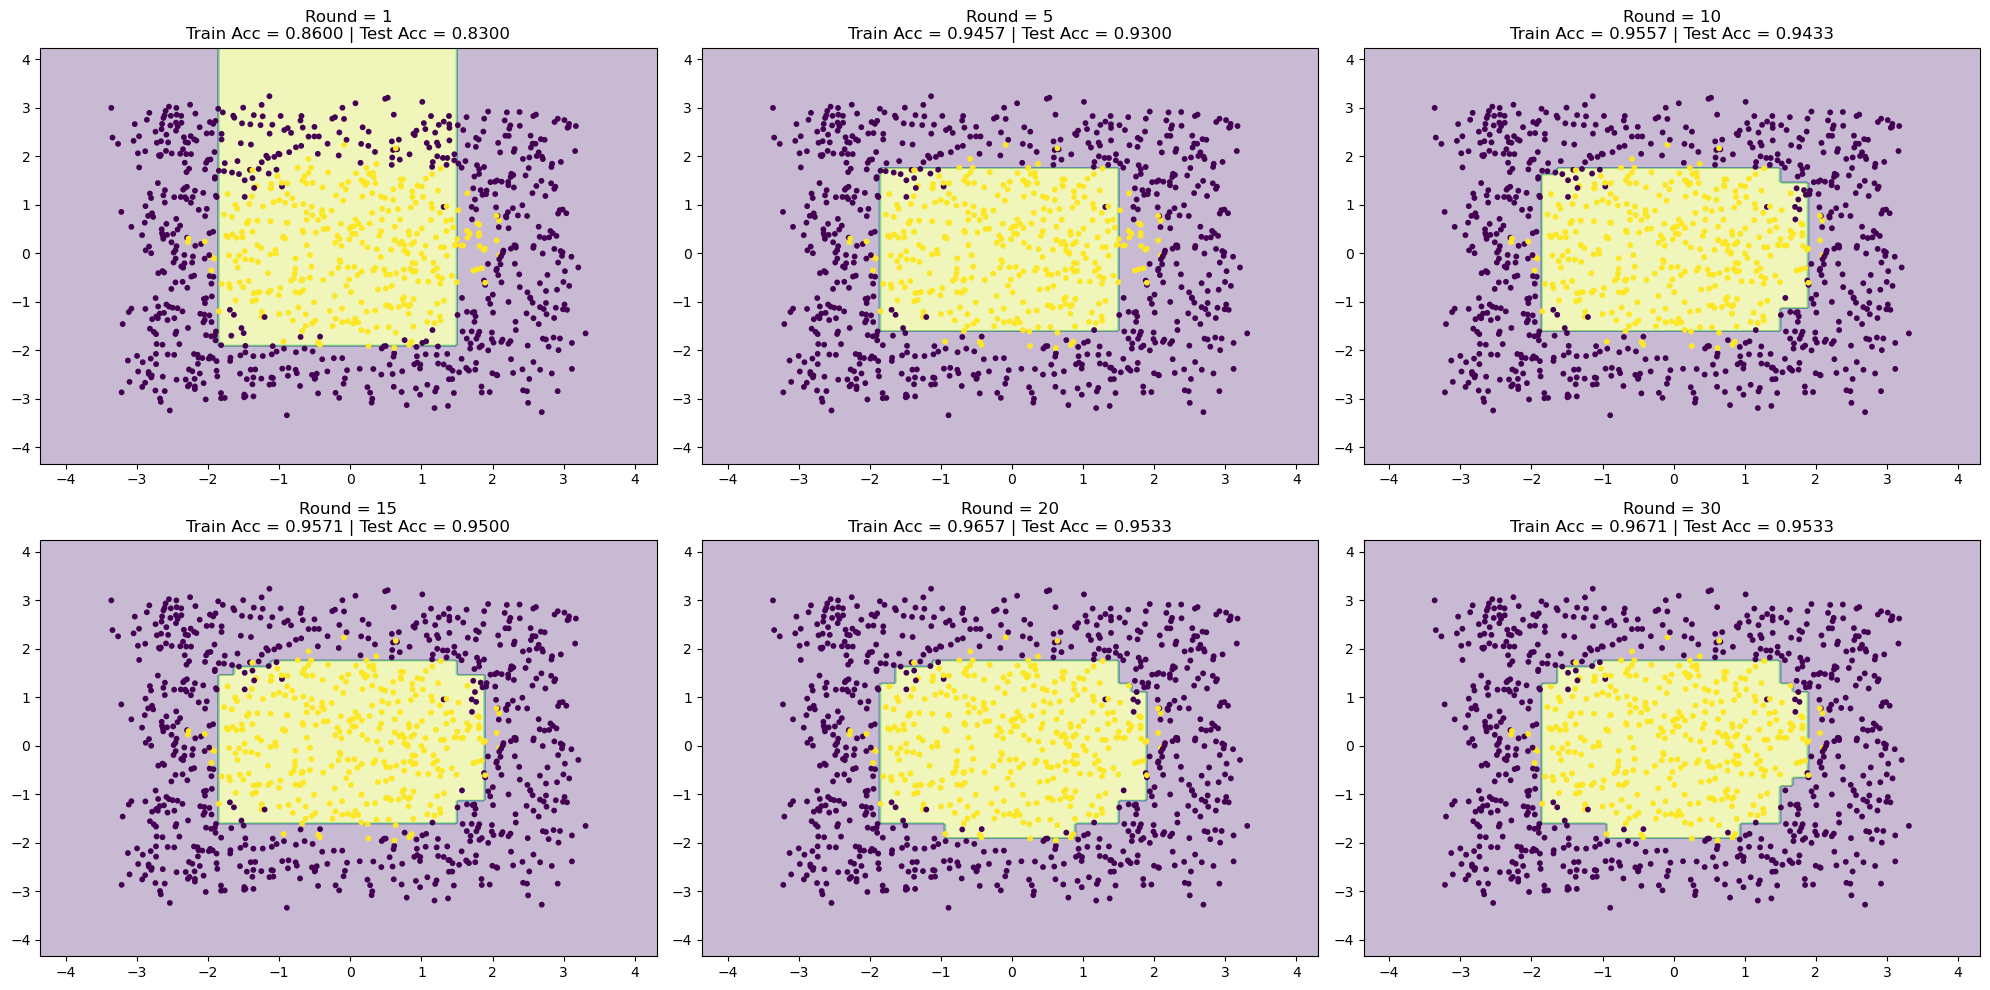

In [10]:
# Plot Evolution

rounds_to_plot = [1, 5, 10, 15, 20, 30]

plt.figure(figsize=(20,10))

for i, m in enumerate(rounds_to_plot):
    
    # Decision boundary
    Z = predict_partial(model, grid, m).reshape(xx.shape)
    
    # Accuracy
    train_pred = predict_partial(model, X_train, m)
    test_pred = predict_partial(model, X_test, m)
    
    train_acc = np.mean(train_pred == y_train)
    test_acc = np.mean(test_pred == y_test)
    
    # Plot
    plt.subplot(2, 3, i+1)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, s=10)
    
    plt.title(
        f"Round = {m}\n"
        f"Train Acc = {train_acc:.4f} | Test Acc = {test_acc:.4f}"
    )

plt.tight_layout()
plt.show()

## 6. Observations

### I Early Rounds ($m = 1, 5$)

- Model is underfitting  
- Decision boundary is simple  
- Accuracy is low  

$$
F_k(x) \approx \text{coarse approximation}
$$



### II Intermediate Rounds ($m = 10, 15$)

- Boundary starts capturing non-linear structure  
- Accuracy improves  

$$
F_k(x) \rightarrow \text{better approximation of true boundary}
$$



### III Later Rounds ($m = 20, 30$)

- Boundary becomes more complex  
- Fine-grained regions appear  

$$
F_k(x) \approx \text{highly flexible function}
$$

- Training accuracy increases  
- Test accuracy may plateau or decrease (overfitting)

---

## 7. Bias-Variance Perspective

- Small $m$:
$$
\text{High Bias, Low Variance}
$$

- Large $m$:
$$
\text{Low Bias, High Variance}
$$

---

## 10. Key Insight

The model evolves as:

$$
F(x) = \sum_{m=1}^{M} \eta \, f^{(m)}(x)
$$

Each iteration:
- Adds a correction  
- Refines the boundary  
- Focuses on previous errors  

---

## 11. Conclusion

- XGBoost builds the decision boundary **incrementally**
- Early trees capture global structure  
- Later trees refine local details  
- Overfitting can occur with too many boosting rounds  

---

## 12. Intuition

- Boosting = **sequential error correction**  
- Trees = **piecewise constant approximations**  
- Final model = **sum of weak learners forming a strong classifier**  

---